Работу выполнила: *Монина Вера*

Задание.

1. Загрузить набор данных (https://www.kaggle.com/datasets/fabiochiusano/medium-articles) либо по архивом с конференции или гугл диск. Предстоит решение задачи мультилейбл классификации. В наборе данных содержится информация о статьях с Medium, целью является предсказание тематических тегов этих статей.
2. Произвести анализ данных, отобрать данные и метки, которые вы хотите/целесообразно использовать в процессе дообучения сети. После отбора в метках должно остаться не менее 25 уникальных тегов.
3. Подобрать модель для дообучения из открытых источников (huggingface подойдет, но можно и другие источники), а также генеративную модель, на которой будет решаться задача Zero-Shot мультилейбл классификация (к использованию подойдут как Encoder-Decoder архитектуры, так и Decoder-only).
4.  Выполнить Fine-Tunning выбранной вами модели, оценить ее качество, пользуясь метриками, подходящими для оценивания задачи мультилейбл классификации.
5.  Сравнить FT (Fine-Tuned) модель с 4-го пункта и выбранную вами Zero-Shot модель (модель, способную делать предсказания на новых данных без дообучения как такового), методы сравнения и метрики на ваше усмотрение.

#0. Установки

In [ ]:
import pandas as pd
from ast import literal_eval
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import torch

In [ ]:
!pip install kaggle

In [ ]:
import kagglehub

In [ ]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1" huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [ ]:
from unsloth import FastLanguageModel

/tmp/ipykernel_5508/2814113929.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer


#1. **Скачивание датасета и EDA**

In [ ]:
path = kagglehub.dataset_download("fabiochiusano/medium-articles")

Using Colab cache for faster access to the 'medium-articles' dataset.


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/medium-articles


In [ ]:
data_path = " /kaggle/input/medium-articles"

In [ ]:
df = pd.read_csv("/kaggle/input/medium-articles/medium_articles.csv")

In [ ]:
df.head()

,title,text,url,authors,timestamp,tags
0,Mental Note Vol. 24,Photo by Josh Riemer on Unsplash\n\nMerry Chri...,https://medium.com/invisible-illness/mental-no...,['Ryan Fan'],2020-12-26 03:38:10.479000+00:00,"['Mental Health', 'Health', 'Psychology', 'Sci..."
1,Your Brain On Coronavirus,Your Brain On Coronavirus\n\nA guide to the cu...,https://medium.com/age-of-awareness/how-the-pa...,['Simon Spichak'],2020-09-23 22:10:17.126000+00:00,"['Mental Health', 'Coronavirus', 'Science', 'P..."
2,Mind Your Nose,Mind Your Nose\n\nHow smell training can chang...,https://medium.com/neodotlife/mind-your-nose-f...,[],2020-10-10 20:17:37.132000+00:00,"['Biotechnology', 'Neuroscience', 'Brain', 'We..."
3,The 4 Purposes of Dreams,Passionate about the synergy between science a...,https://medium.com/science-for-real/the-4-purp...,['Eshan Samaranayake'],2020-12-21 16:05:19.524000+00:00,"['Health', 'Neuroscience', 'Mental Health', 'P..."
4,Surviving a Rod Through the Head,"You’ve heard of him, haven’t you? Phineas Gage...",https://medium.com/live-your-life-on-purpose/s...,['Rishav Sinha'],2020-02-26 00:01:01.576000+00:00,"['Brain', 'Health', 'Development', 'Psychology..."


In [ ]:
def parsing(x):
    parsed = literal_eval(x)
    if isinstance(parsed, (list, tuple)):

      return [t.strip() for t in parsed]

# распарсили теги в более удобный формат)
df['tags_list'] = df['tags'].apply(parsing)

In [ ]:
all_tags = [t for tags in df['tags_list'] for t in tags]

uniq = Counter(all_tags)
num_unique_tags = len(uniq)

print("Количество уникальных тегов в датасете до отчистки:", num_unique_tags)

Количество уникальных тегов в датасете до отчистки: 78635


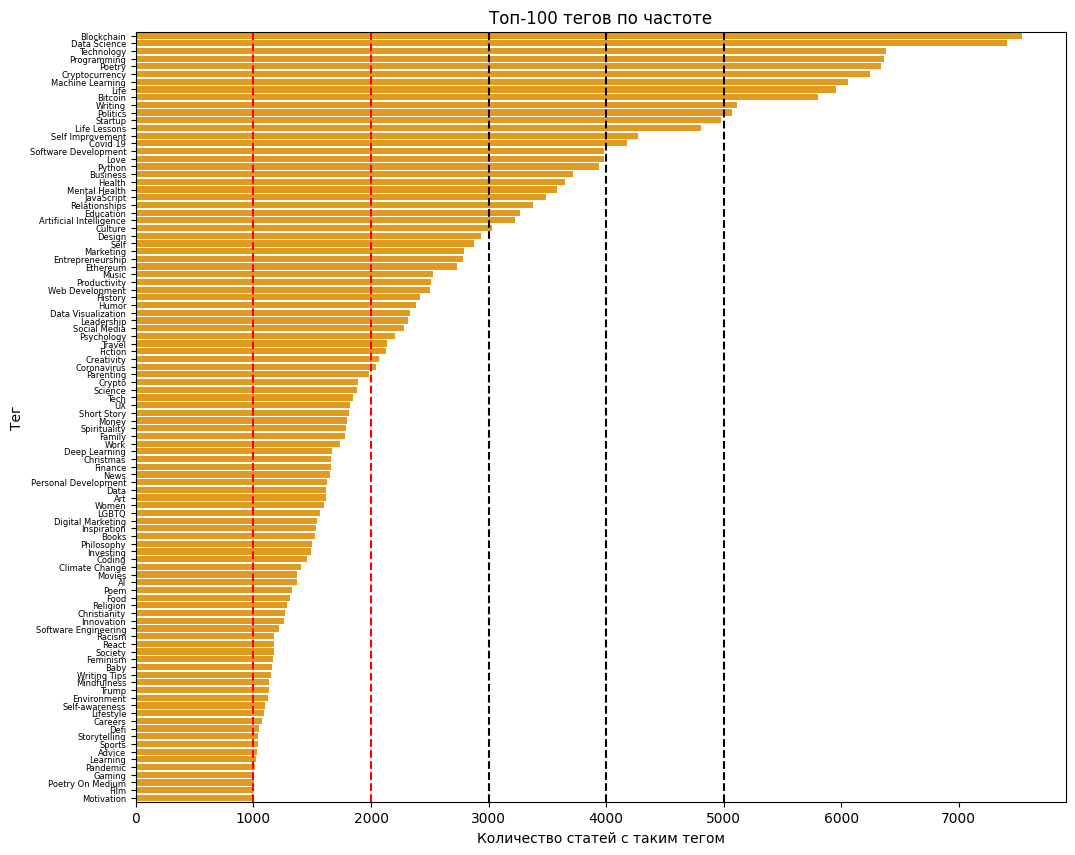

In [ ]:
tag_freq = pd.DataFrame(uniq.items(), columns=['tag', 'count']).sort_values('count', ascending=False)
plt.figure(figsize=(12,10))
ax = sns.barplot(x='count', y='tag', color='orange', data=tag_freq.head(100))
ax.tick_params(axis='y', labelsize=6)
ax.axvline(x=1000, linestyle='--', color='red')
ax.axvline(x=2000, linestyle='--', color='red')
ax.axvline(x=3000, linestyle='--', color='black')
ax.axvline(x=4000, linestyle='--', color='black')
ax.axvline(x=5000, linestyle='--', color='black')
plt.title("Топ-100 тегов по частоте")
plt.xlabel("Количество статей с таким тегом")
plt.ylabel("Тег")
plt.show()

Как мы видим из графика распределения топ-100 тегов, ≈50 тегов подходят <2000 статьям. Остальная половина распределена от 2000 статей до 7000 статей.

Если обрезать по 1000, то получится слишком большой датасет, боюсь, что мой компик не потянет такое количество)


In [ ]:
df['num_tags'] = df['tags_list'].apply(len)
mean_tags = df['num_tags'].mean()

print("Среднее количество тегов на статью до отчистки:", mean_tags)

Среднее количество тегов на статью до отчистки: 4.577684438160193


In [ ]:
num_no_tags = (df['num_tags'] == 0).sum()

print("Количество статей без тегов:", num_no_tags)

Количество статей без тегов: 0


#2. **Отбор тегов**

In [ ]:
limit = 2000 # как я уже писала выше, если выставлять ограничение 1000 или меньше, то получается ооочень большой датасет, поэтому я сразу беру довольны высокое ограничение в 2000 статей
# чтобы посмотреть сколько тогда топ тегов останется

# я также пробовала дообучить при ограничении 500 тегов, но я не дождалась конца, потому что коллаб начал вылетать

selected_tags = [t for t,c in uniq.items() if c >= limit]


print("Количество тегов после отчистки:", len(selected_tags))

# оставляем только те статьи, у которых есть хотя бы один выбранный тег
def filter_articles(df, selected_tags):
    selected_set = set(selected_tags)
    df['filtered_tags'] = df['tags_list'].apply(lambda x: [t for t in x if t in selected_set])
    df_filtered = df[df['filtered_tags'].map(len) > 0].copy()
    return df_filtered

df_filtered = filter_articles(df, selected_tags)
print("Количество статей после отчистки:", len(df_filtered))

Количество тегов после отчистки: 44
Количество статей после отчистки: 102958


*насколько я поняла условие, не обязательно должно быть взято ровно топ-30 тегов, поэтому я решила немного расширить эту границу до топ-40 тегов, чтобы граница проходила почти ровно по ограничению в min 2000 статей на тег

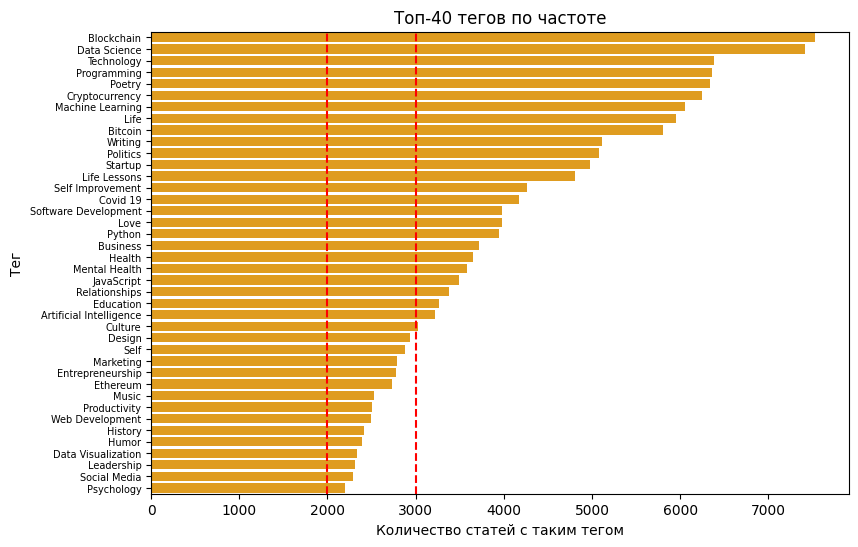

In [ ]:
tag_freq = pd.DataFrame(uniq.items(), columns=['tag', 'count']).sort_values('count', ascending=False)
plt.figure(figsize=(9,6))
ax = sns.barplot(x='count', y='tag', color='orange', data=tag_freq.head(40))
ax.tick_params(axis='y', labelsize=7)
ax.axvline(x=2000, linestyle='--', color='red')
ax.axvline(x=3000, linestyle='--', color='red')
plt.title("Топ-40 тегов по частоте")
plt.xlabel("Количество статей с таким тегом")
plt.ylabel("Тег")
plt.show()

In [ ]:
# оставляем топ-40 (для ровного числа)
tag_counts_filtered = Counter([t for tags in df_filtered['filtered_tags'] for t in tags])
tag_freq_df = pd.DataFrame(tag_counts_filtered.items(), columns=['tag', 'count']).sort_values('count', ascending=False)

top_tags = tag_freq_df.head(40)['tag'].tolist()

In [ ]:
df_filtered['input_text'] = (
    df_filtered['title'].fillna('') +
    df_filtered['text'].fillna('').str[:400]
) # еще и обрезаю немного тексты, чтобы они были одинаковой длины

In [ ]:
print('Пример:\n\n')
print(df_filtered['input_text'].iloc[0][:300])
print("\n\nТеги:", df_filtered['filtered_tags'].iloc[0])

Пример:


Mental Note Vol. 24Photo by Josh Riemer on Unsplash

Merry Christmas and Happy Holidays, everyone!

We just wanted everyone to know how much we appreciate everyone and how thankful we are for all our readers and writers here. We wouldn’t be anywhere without you, so thank you all for bringing informa


Теги: ['Mental Health', 'Health', 'Psychology']


#3. **Fine-tuning**

Для файн-тюнинга я выбрала самый базовый и распространненный берт, которые выдается первым при поиске берата: https://huggingface.co/google-bert/bert-base-uncased (+ на последней паре сказали, что для этой задачки лучше всего брать берт :) )

Также этот берт был обучен на английском материале (мне было важно, чтобы модель была не мультилингвал, потому что это могло бы привести к дополнительным лоссам)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
x = len(top_tags)

In [ ]:
model_f = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=40,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
bin = MultiLabelBinarizer(classes=top_tags)
# тут делаем one-hot кодирование тегов
y = bin.fit_transform(df_filtered['filtered_tags'])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Coronavirus', 'Creativity', 'Fiction', 'Travel'] will be ignored
  warnings.warn(


In [ ]:
X = df_filtered['input_text'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
print("количество статей в train:", len(X_train), "количество статей в test:", len(X_test))

количество статей в train: 82366 количество статей в test: 20592


In [ ]:
train_encodings = tokenizer(list(X_train), padding="max_length", truncation=True, max_length=256)
test_encodings  = tokenizer(list(X_test),  padding="max_length", truncation=True, max_length=256)

In [ ]:
class MyDataset(Dataset):
    def __init__(self, tokenized_texts, tag_labels):
        self.texts = tokenized_texts   # токенизированные тексты
        self.labels = tag_labels

    def __len__(self):
        return len(self.labels)        # сколько всего примеров

    def __getitem__(self, index):
        # берём один пример
        data = {key: torch.tensor(val[index]) for key, val in self.texts.items()}
        data["labels"] = torch.tensor(self.labels[index], dtype=torch.float)
        return data


In [ ]:
# создаём датасеты по нашему образцу
train_dataset = MyDataset(train_encodings, y_train)
test_dataset  = MyDataset(test_encodings, y_test)

In [ ]:
def compute_metrics(eval_pred):
    raw_logits, true_labels = eval_pred

    probabilities = torch.sigmoid(torch.from_numpy(raw_logits)).numpy() # переводим в вероятности
    binary_preds = (probabilities >= 0.3).astype(int) # мне кажется, что это очень важный момент, тут я взяла порог = 0.3, то есть
    # Если вероятность ≥ 0.3 → считаем, что тег подходит (ставим 1)
    # Если вероятность < 0.3 → считаем, что тег не подходит (ставим 0)

    # изначально, я работала с порог = 0.5 и получала результаты хуже, потом прочитала, что при fine-tuning на небольших данных
    # можно попробовать поставить порог пониже, потому что модель может занижать вероятности
    try:
        roc_auc = roc_auc_score(true_labels, probabilities, average="macro")
    except ValueError:
        roc_auc = None

    return {
        "f1_weighted": f1_score(true_labels, binary_preds, average="weighted", zero_division=0),
        "f1_micro": f1_score(true_labels, binary_preds, average="micro", zero_division=0),
        "f1_macro": f1_score(true_labels, binary_preds, average="macro", zero_division=0),
        "precision_weighted": precision_score(true_labels, binary_preds, average="weighted", zero_division=0),
        "recall_weighted": recall_score(true_labels, binary_preds, average="weighted", zero_division=0),
        "roc_auc_macro": roc_auc
    }

**Выбранные метрики для оценки дообучения модели**:
- F1-weighted

Считается как взвешенное среднее F1 по всем классам. Эта метрика должна показывать общую эффективность дообучения модели (именно поэтому в training я буду сохранять вот так: metric_for_best_model="f1_weighted")

- F1 micro

Суммируются все true posotive, false positive, false negative результаты по всем классам и потом считает по формуле: F1 = 2*TP / (2*TP + FP + FN)

- F1 macro

Считается F1 для каждого класса отдельно и затем берётся среднее арифметическое. Должна лучше учитывать редкие классы (учитывая, что у нас в тегах есть некоторых дисбаланс, эта метрика может быть достаточно полезной)

- Precision weighted

Доля правильных предсказаний среди всех положительных (true positive / (true positive + false posotive))

- Recall weighted

Доля найденных правильных тегов среди всех возможных

- ROC AUC macro

усредненная по классам площадь под ROC-кривой, важно, что эта метрика работает непосредственно с веротяностями классов, а не с их бинарными смыслами (True - правильно угадал тег, False - неправильно).

In [ ]:
class MyMultiLabelTrainer(Trainer):
    def compute_loss(self, model, batch, return_outputs=False, **kwargs):
        # достаём метки из батча
        batch_labels = batch.pop("labels")

        # прогоняем данные через модель
        result = model(**batch)

        # считаем стандартный BCE лосс для multi-label
        criterion = torch.nn.BCEWithLogitsLoss()
        loss = criterion(result.logits, batch_labels)

        # возвращаем лосс
        if return_outputs:
            return loss, result
        return loss

In [ ]:
traintrain = TrainingArguments(
    output_dir="./results_fine_tuning", # сохраняю промежуточные результаты сюда (после каждой эпохи)
    # потому что когда я потом подгружаю модель для zero-shot среда слетает и надо иметь возможность обратиться
    # к дообученной модели
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=0.00003, # пробовала lr=0.001, были ооочень плохие резы, другие параметры не пробовала

    # логируем каждые 1000 шагов
    logging_strategy="steps",
    logging_steps=1000,

    # оцениваем на тесте каждую эпоху
    eval_strategy="epoch",

    # сохраняем модель после каждой эпохи
    save_strategy="epoch",

    fp16=True,
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True
)

In [ ]:
trainer = MyMultiLabelTrainer(
    model=model_f,
    args=traintrain,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Weighted,F1 Micro,F1 Macro,Precision Weighted,Recall Weighted,Roc Auc Macro
1,0.103163,0.091798,0.495666,0.540695,0.465865,0.551942,0.520657,0.925723
2,0.083701,0.085824,0.549770,0.571420,0.527790,0.563328,0.565098,0.936050
3,0.074345,0.085380,0.558943,0.571019,0.537937,0.562750,0.573484,0.936985
4,0.066029,0.085936,0.564250,0.572025,0.543521,0.555803,0.585523,0.936286
5,0.060807,0.087150,0.563650,0.569231,0.542463,0.546835,0.591031,0.934904


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=12870, training_loss=0.0819021116788756, metrics={'train_runtime': 5601.8582, 'train_samples_per_second': 73.517, 'train_steps_per_second': 2.297, 'total_flos': 5.419699795070976e+16, 'train_loss': 0.0819021116788756, 'epoch': 5.0})

**Анализ результатов и выбор лучшей модели:**
- Эпоха 1

Низкие показатели F1 (0.49-0.54), высокий Precision (0.55) при более низком Recall (0.52)

- Эпоха 2

Видим значительное улучшение всех метрик. Достигается хороший баланс между Precision и Recall (0.56/0.57). F1 микро достигает своего максимума, что говорит о том, что на этой эпохе модель достигла наилучшего баланса в предсказаниях для всех объектов сразу

- Эпоха 3

Validation loss достигает своего минимума (0.08538). F1 Weighted и F1 Macro продолжают расти, достигая, практически, своих самых высоких значений (0.558 и 0.537 соответственно). параметр ROC AUC достигает максимума (0.9369)


- Эпоха 4

F1 Weighted и F1 Macro достигает абсолютного максимума (0.564/0.543521), Recall продолжает расти, однако Precision снижается, а validation loss начинает немного возрастать, что может указывать на начало переобучения

- Эпоха 5
Наблюдается ухудшение большинства метрик


---


Мне кажется, что лучше всего использовать эту модель в состоянии на этапе **третьей** эпохи, потому что достигаются:

- минимальное значение validation loss
- баланс precision / recall
- хорошие значения F1
- максимальное значение ROC AUC

А после этой эпохи начинается рост validation loss и другие метрики то ухудшаются, то растут, что сигнализирует о переобучении

Отдельно про метрику ROC AUC:
значение ≈0.94 означает, что модель одинаково хорошо ранжирует как частотные  (7000 статей), так и редкие (2000 статей) теги. То есть правильные теги почти всегда получают более высокие вероятности, чем неправильные вне зависимости от частотности тега в датасете.

#4. **Zero-shot**

Я побоялась работать с АPI ключом, потому что вдруг что... поэтому я нашла такую тетрадку, в которой есть квантизированные модели, которыми можно пользоваться напрямую без ключа
https://colab.research.google.com/drive/1Ys44kVvmeZtnICzWz0xgpRnrIOjZAuxp?usp=sharing

Я выбрала llama

In [ ]:
model_zs1, tokenizer_zs1 = FastLanguageModel.from_pretrained(
    model_name="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length=512,
    dtype=None,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model_zs1)

==((====))==  Unsloth 2026.3.4: Fast Llama patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/meta-llama-3.1-8b-instruct-bnb-4bit as a legacy tokenizer.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

*при таком промпте получились наивысшие результаты:*

In [ ]:
prompt_template = """You are a text classification assistant.
Pick only tags that are clearly relevant to the article topic.
If unsure about a tag — skip it. Better to pick fewer but correct tags.
Respond ONLY with comma-separated tags. No explanation. Maximum 5 tags per article.
### Article:
{}

### Available tags:
{}

### Response:
"""

Примеры промптов, которые я также тестировала:

1.
> You are a text classification assistant.
Given an article, select relevant tags from the provided list.
Respond ONLY with comma-separated tags. No explanation.

- F1 weighted:        0.1358
- Precision weighted: 0.0742
- Recall weighted:    0.9545




2.
> You are a text classification assistant.
Given an article, select 3-5 most relevant tags from the provided list.
Respond ONLY with comma-separated tags. No explanation. Maximum 5 tags.


- F1 weighted:        0.2877
- Precision weighted: 0.1935
- Recall weighted:    0.7045



3.
> Task: multi-label classification of a Medium article.

> Pick only tags that are clearly relevant to the article topic.
If unsure about a tag — skip it. Better to pick fewer but correct tags.
Respond ONLY with comma-separated tags. No explanation. Maximum 5 tags per article.
Choose tags exclusively from the provided list. Do not create new tags.
Example:


> Article: "Daily cleaning and maintenance of bedding When cleaning products of different materials, the following points need to be paid attention to: 1. when cleaning, please do not use bleach, high temperature hot water, hot and cold water. 2.When washing dark bed products, the soaking time should not exceed 10 minutes. Do not wash locally, rub in a large area, and do not mix and wash with other light-colored fabrics. 3.bedding should be washed when changing seasons, and store in a dry place after drying. Before washing and maintenance we should check the washing logo of each product. 1. silk or silk cotton products 【Washing】 Dry cleaning is the best way. If the label indicates that it can be washed by water, Please add an appropriate amount of neutral soap or mild soap to the warm water and wait for the soap to melt and the water cools down, then immerse the product and gently rub it."

> Available tags: bedding, cleaning, maintain

> Response: bedding, cleaning, maintain

> Now, analyze the following article and select the appropriate tags.


- F1 weighted:
 0.2422

- F1 micro:
 0.1934

- F1 macro:
0.2102

- Precision weighted:
0.1574

- Recall weighted:
0.7101

Я была удивлена, что при самом длинном промпте с дополнительным примером (который при оценке не использовался (я брала его из конца датасета)) результаты получились не самыми лучшими. Я думала, что чем длиннее и распространнее, тем лучше. Оказалось, что не всегда.

Видимо, детальные инструкция + пример (как промпт 3) неожиданно ухудшили точность, потому что модель переобучалась на примере и начинала искать похожие темы, а не строго следовать правилу "лучше меньше, но точнее".

Но самых оптимальных результатов удалось достичь при помощи промпта, который я в итоге оставила.


In [ ]:
def predict_tags_zeroshot(text, candidate_tags, max_text_length=400):
    truncated_text = text[:max_text_length]

    tags_str = ", ".join(candidate_tags)
    prompt = prompt_template.format(truncated_text, tags_str)

    # у меня были ошибки, связанные с тем, что контекст длинее, чем влещает в модель
    # и поэтому я явно обрезаю все контексты, чтобы не было лишних warning-ов
    inputs = tokenizer_zs1(
        prompt,
        return_tensors="pt",
        truncation=True,          # обрезаем
        max_length=512,           # до лимита модели
        padding=False).to("cuda")

    with torch.no_grad():
        outputs = model_zs1.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=tokenizer_zs1.eos_token_id)

    response = tokenizer_zs1.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True)

    # вручную убираю дубликаты, есои такие есть (при тестовых прогонах я такого не заметила, но на всякий случай вставила)
    lower_to_original = {tag.lower(): tag for tag in candidate_tags}
    predicted_raw = [t.strip().lower() for t in response.split(",") if t.strip()]

    before = set()
    unique_predicted = []
    for i in predicted_raw:
        if i not in before and i in lower_to_original:
            before.add(i)
            unique_predicted.append(i)

    # эта строчка решает проблему, с которой я столкнулась --> модель сама выбирала регистр, в котором
    # она возвращала теги, поэтому мои метрики были на 0, поэтому я вручную все привожу к верхнему,
    # чтобы совпадало с тем, что в нашем датасете
    valid_tags = [lower_to_original[t] for t in unique_predicted if t in lower_to_original]
    return valid_tags

In [ ]:
# Инференс (мне кажется, что прогонять на всех статьях бессмысленно, потому что их слишком много, только время потратится)
# надеюсь, что 1200 достаточно, чтобы оценить
articles_num = 1200
zs_predictions1 = []

In [ ]:
for i, text in enumerate(X_test[:articles_num]):
    predicted = predict_tags_zeroshot(text, top_tags)
    zs_predictions1.append(predicted)

    if i % 150 == 0: # вывожу каждые 150, чтобы убедиться, что модель верно понимает мой промпт
        print(f"\n[{i} article из {articles_num}]")
        print(f"Предсказанные теги: {predicted}")


[0 article из 1200]
Предсказанные теги: ['Life', 'Relationships', 'Entrepreneurship', 'Self Improvement', 'Writing', 'Business', 'Marketing', 'Technology', 'Startup', 'Life Lessons', 'Self']

[150 article из 1200]
Предсказанные теги: ['Life']

[300 article из 1200]
Предсказанные теги: ['Entrepreneurship', 'Business', 'Self Improvement', 'Life Lessons']

[450 article из 1200]
Предсказанные теги: ['Life', 'Relationships', 'Writing', 'History']

[600 article из 1200]
Предсказанные теги: ['Life', 'Self Improvement', 'Writing']

[750 article из 1200]
Предсказанные теги: ['Cryptocurrency', 'Blockchain']

[900 article из 1200]
Предсказанные теги: ['Machine Learning', 'Data Science', 'Programming', 'Life']

[1050 article из 1200]
Предсказанные теги: ['Web Development', 'Software Development', 'Business', 'Entrepreneurship']


К сожалению, ни при одном из вариантов промптов модель не перестала выдавать больше 5 тегов на статью, хотя я явно об этом прошу в достаточно строгой и четкой манере. Но из-за этой особенности получается высокий Recall)

In [ ]:
y_zs = bin.transform(zs_predictions1)

In [ ]:
f1_w_zero = f1_score(y_test[:articles_num], y_zs[:articles_num], average='weighted', zero_division=0)
f1_micro_zero = f1_score(y_test[:articles_num],  y_zs[:articles_num], average='micro', zero_division=0)
f1_macro_zero = f1_score(y_test[:articles_num],  y_zs[:articles_num], average='macro', zero_division=0)
prec_zero = precision_score(y_test[:articles_num],  y_zs[:articles_num], average='weighted', zero_division=0)
rec_zero = recall_score(y_test[:articles_num], y_zs[:articles_num], average='weighted', zero_division=0)

In [ ]:
print("Zero-Shot Llama-3.1-8B results on 1200 selected articles")

print(f"F1 weighted:\n {f1_w_zero:.4f}")
print(f"\nF1 micro:\n {f1_micro_zero:.4f}")
print(f"\nF1 macro:\n{f1_macro_zero:.4f}")
print(f"\nPrecision weighted:\n{prec_zero:.4f}")
print(f"\nRecall weighted:\n{rec_zero:.4f}")

Zero-Shot Llama-3.1-8B results on 1200 selected articles
F1 weighted:
 0.3917

F1 micro:
 0.3448

F1 macro:
0.3673

Precision weighted:
0.3055

Recall weighted:
0.6636


Как я скажу далее, самый главный плюс данной модели -- высокие показатели Recall, потому что модель предсказывает достаточно много тегов, которые перекрывают большинство правильных.

Результаты по метрикам F1 macro (0.3673) и F1 weighted (0.3917) достаточно близки — значит, модель работает относительно равномерно по всем тегам, нет сильного перекоса в сторону каких-то определенных частотных классов.

F1 micro (0.3448) оказался ниже — это подтверждает, что на уровне отдельных предсказаний (а не классов) модель ошибается чаще из-за большого количества неправильно предсказанных тегов.

##4.2

Раздел для получения результатов дообученного Берта на этих же статьях

In [ ]:
model_path = "/content/results_fine_tuning/checkpoint_7722"

In [ ]:
model_f_new = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=len(top_tags),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
trainer = Trainer(
    model=model_f_new
)

In [ ]:
ft_output = trainer.predict(MyDataset(
    tokenizer(list(X_test[:articles_num]), padding="max_length", truncation=True, max_length=256),
    y_test[:articles_num]
))

ft_probs = torch.sigmoid(torch.tensor(ft_output.predictions)).numpy()
y_ft = (ft_probs >= 0.3).astype(int)

In [ ]:
f1_w_fine= f1_score(y_test[:articles_num], y_ft, average='weighted', zero_division=0)
f1_micro_fine = f1_score(y_test[:articles_num], y_ft, average='micro', zero_division=0)
f1_macro_fine = f1_score(y_test[:articles_num], y_ft, average='macro', zero_division=0)
prec_fine = precision_score(y_test[:articles_num], y_ft, average='weighted', zero_division=0)
rec_fine = recall_score(y_test[:articles_num], y_ft, average='weighted', zero_division=0)

In [ ]:
print("Fine-tuned BERT results on the same 1200 articles")
print(f"F1 weighted:\n{f1_w_fine:.4f}")
print(f"\nF1 micro:\n{f1_micro_fine:.4f}")
print(f"\nF1 macro:\n{f1_macro_fine:.4f}")
print(f"\nPrecision weighted:\n{prec_fine:.4f}")
print(f"\nRecall weighted:\n{rec_fine:.4f}")

Fine-tuned BERT results on the same 1200 articles
F1 weighted:
0.5682

F1 micro:
0.5767

F1 macro:
0.5435

Precision weighted:
0.5761

Recall weighted:
0.5808


#5. Сравнение

In [ ]:
# метрики для Fine-Tuned BERT -- беру сохраненные значения из принтов, а не сами переменные,
# потому что весь код выполнялся в несоклько шагов
precision_ft = 0.5761
recall_ft    = 0.5808
f1_ft        = 0.5682

# метрики для Zero-Shot Llama -- аналогично
precision_zs = 0.3055
recall_zs    = 0.6636
f1_zs        = 0.3917


md = ["Fine-Tuned BERT", "Zero-Shot Llama"]
metrics_names = ['Precision', 'Recall', 'F1 Weighted']
precision_scores = [precision_ft, precision_zs]
recall_scores    = [recall_ft, recall_zs]
f1_scores        = [f1_ft, f1_zs]

# Вычисляем разницу (дельту) между BERT и Zero-Shot для каждой метрики
delta_precision = precision_ft - precision_zs
delta_recall    = recall_ft - recall_zs
delta_f1        = f1_ft - f1_zs

deltas = [delta_precision, delta_recall, delta_f1]
delta_colors = ['darkblue' if d > 0 else 'darkred' for d in deltas]

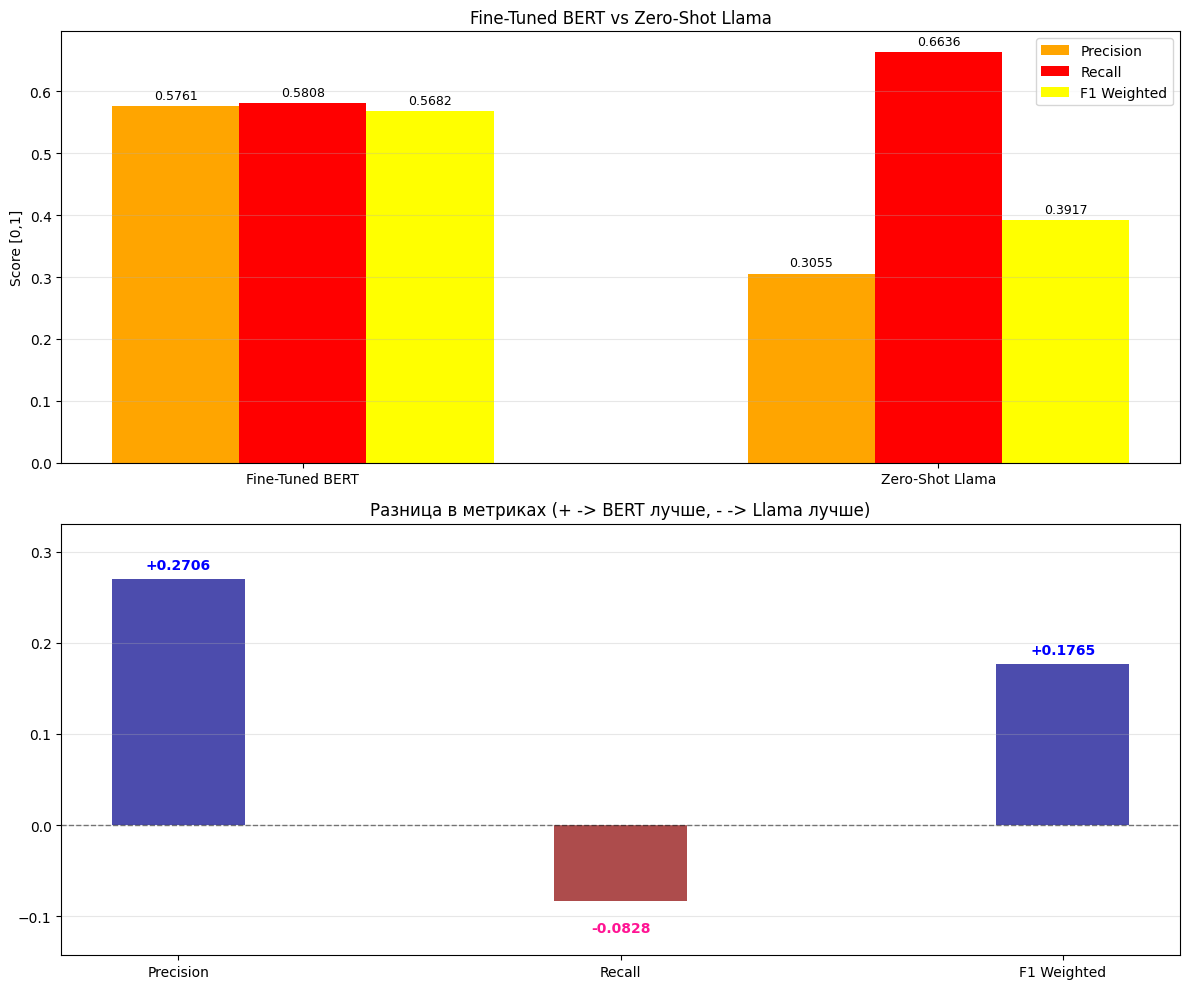

In [ ]:
x = np.arange(len(md))
bar= 0.2
# Создаем график с двумя subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

bars1 = ax1.bar(x - bar, precision_scores, bar, label='Precision', color='orange')
bars2 = ax1.bar(x, recall_scores, bar, label='Recall', color='red')
bars3 = ax1.bar(x + bar, f1_scores, bar, label='F1 Weighted', color='yellow')
ax1.set_ylabel('Score [0,1]')
ax1.set_title('Fine-Tuned BERT vs Zero-Shot Llama')
ax1.set_xticks(x)
ax1.set_xticklabels(md)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')


def add_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

add_labels(bars1, ax1)
add_labels(bars2, ax1)
add_labels(bars3, ax1)

#--
x_delta = np.arange(len(metrics_names))
bars_delta = ax2.bar(x_delta, deltas, bar*1.5, color=delta_colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)


ax2.set_title('Разница в метриках (+ -> BERT лучше, - -> Llama лучше)')
ax2.set_xticks(x_delta)
ax2.set_xticklabels(metrics_names)
ax2.set_ylim(min(deltas) - 0.06, max(deltas) + 0.06)
ax2.grid(True, alpha=0.3, axis='y')


for i, (bar, delta) in enumerate(zip(bars_delta, deltas)):
    height = bar.get_height()
    color = 'blue' if delta > 0 else 'deeppink'
    ax2.annotate(f'{delta:+.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5 if delta > 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if delta > 0 else 'top',
                fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.show()


**Выводы**:


| Метрика | BERT (fine-tuned) | Llama (zero-shot) | Разница | Интерпретация |
|---------|-------------------|-------------------|---------|---------------|
| **Precision** | 0.5761 | 0.3055 | **+0.2706** (BERT лучше) | BERT ошибается в **~3.7 раза реже** при предсказании тегов |
| **Recall** | 0.5808 | 0.6636 | **-0.0828** (Llama лучше) | Llama находит на **14% больше** верных тегов |
| **F1-score** | 0.5682 | 0.3917 | **+0.1765** (BERT лучше) | BERT показывает **более сбалансированный** результат между полнотой и точностью |

Мне кажется, что оба варианта работы с такой задачей имеют место быть:
- С zero-shot Llam-ой можно работать, есть нам нужна какая-то быстрая и первичная разметка. Например, если бы у нас был бы только набор неразмеченных текстов и список тегов, то тогда можно пользоваться таким методом. Потому что мы с большей вероятностью не пропустим какой-то релевантный тег. Для первичной разметки это самое важное.
- С fine-tuned BERT стоит работать, когда у нас уже есть размеченные данные и мы выходим в продакшн, потому что модель будет стабильно выдавать точные предсказания, без лишних тегов.

Мысли на будущее:
для fine-tuning задачи было бы еще интересено посмотреть на decoder-encoder модель

для второго задания есть такие еще идеи, на которые не хватило пока сил:
1) я видела уже использовала эту модель для пары других задач на английском, но я ни разу не учитывала, что эта модель -- мультиязычная. может быть если взять моноязычную модель, то результаты были бы выше. например, mistral или gemma
2) при работе с моделью можно было еще поиграть с гипер-параметрами temperature, top_p, top_k. я работала с ними в рамках курсовой работы, там можно интересно настроить всё, но это требует много экспериментов. для первичной разметки достаточно того, что стоит по дефолту ( "temperature": 1.0,  "top_p": 1.0, "top_k": 50)
